In [1]:
library("splines2")


Call:
lm(formula = extended_cumsums ~ bSpline(extended_vals, degree = 5))

Residuals:
         1          2          3          4          5          6          7 
-4.755e-05  1.441e-03 -2.859e-03 -1.127e-03  8.065e-03 -8.546e-03  3.277e-03 
         8 
-2.036e-04 

Coefficients:
                                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)                          4.755e-05  8.955e-03   0.005  0.99625    
bSpline(extended_vals, degree = 5)1  4.580e-01  1.477e-01   3.101  0.09013 .  
bSpline(extended_vals, degree = 5)2 -1.068e+00  2.272e-01  -4.701  0.04239 *  
bSpline(extended_vals, degree = 5)3  1.392e+00  1.890e-01   7.361  0.01796 *  
bSpline(extended_vals, degree = 5)4  9.417e-01  8.396e-02  11.216  0.00786 ** 
bSpline(extended_vals, degree = 5)5  1.000e+00  1.266e-02  78.979  0.00016 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.008955 on 2 degrees of freedom
Multiple R-squared:  0.9999,	Adjusted R

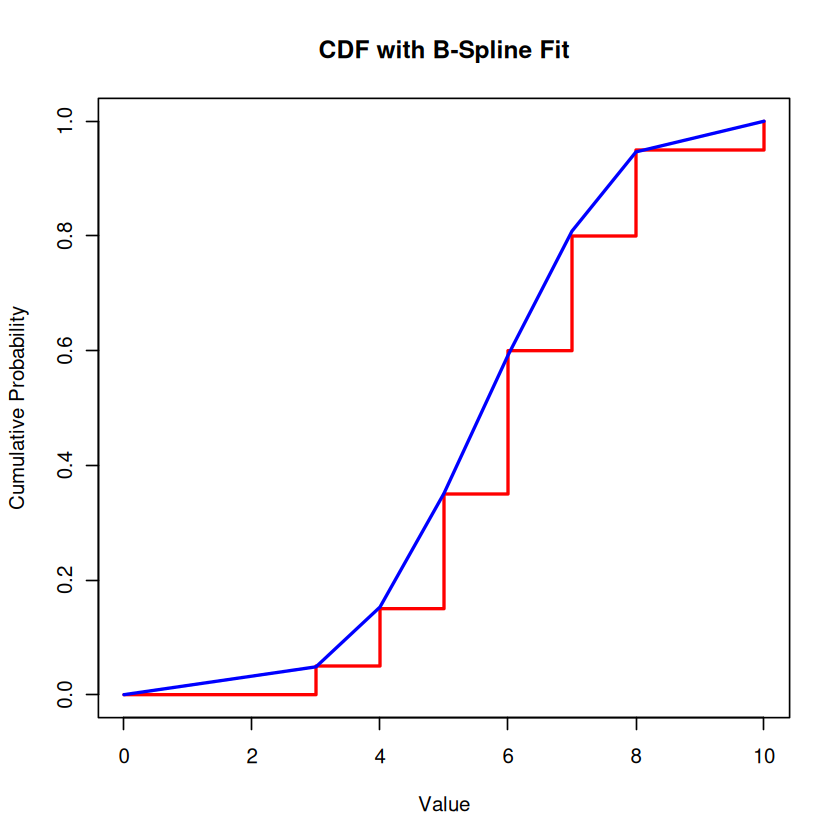

In [2]:
# Values representing the bin edges (right edges of bins)
vals <- c(3, 4, 5, 6, 7, 8)

# Cumulative probabilities for these bins
cumsums <- c(0.05, 0.15, 0.35, 0.6, 0.8, 0.95)

# Define the limits
lower_limit <- 0
upper_limit <- 10

# Adjust the cumulative probabilities to account for the limits
extended_vals <- c(lower_limit, vals, upper_limit)
extended_cumsums <- c(0, cumsums, 1)

# Fit the B-spline to the extended CDF data (force the spline to meet at limits)
cdf_bspline_fit <- lm(extended_cumsums ~ bSpline(extended_vals, degree = 5))

# Show the summary of the fitted B-spline model
summary(cdf_bspline_fit)

# Create the plot for cumulative distribution function
plot(extended_vals, extended_cumsums, type = "s", col = "red", lwd = 2, 
     xlim = c(lower_limit, upper_limit), ylim = c(0, 1),
     xlab = "Value", ylab = "Cumulative Probability", 
     main = "CDF with B-Spline Fit")

# Add the B-spline fit to the plot
lines(extended_vals, predict(cdf_bspline_fit), col = "blue", lwd = 2)

In [3]:
extended_vals

[1]  0  3  4  5  6  7  8 10

In [4]:
diff(predict(cdf_bspline_fit))

2          3          4          5          6          7          8 
0.04851148 0.10429970 0.19826799 0.24080852 0.21661098 0.13817674 0.05348064

In [5]:
# Optionally, plot the derivative to see the PDF
# Calculate the derivative of the fitted CDF (PDF)
cdf_bspline_derivative <- diff(predict(cdf_bspline_fit)) / diff(extended_vals)

# Check the integral of the PDF (it should be close to 1)
integral_check <- sum(cdf_bspline_derivative * diff(extended_vals))
cat("Integral of the PDF: ", integral_check, "\n")

# Normalize the PDF to ensure it integrates to 1
cdf_bspline_derivative_normalized <- cdf_bspline_derivative / integral_check

# Extend the derivative to match the entire range including the last point (upper limit)
#extended_pdf_vals <- c(cdf_bspline_derivative_normalized[1], cdf_bspline_derivative_normalized)  # Add the first value at the start
#extended_vals_pdf <- seq(lower_limit, upper_limit, length.out = length(extended_pdf_vals))

extended_pdf_vals <-  cdf_bspline_derivative_normalized
extended_vals_pdf <- extended_vals
# Plot the PDF derived from the derivative, making sure it aligns with the original bins
lines(extended_vals_pdf, extended_pdf_vals, col = "green", lwd = 2)

Integral of the PDF:  1.000156 


ERROR: Error in xy.coords(x, y): 'x' and 'y' lengths differ


In [83]:
extended_vals

[1]  0  3  4  5  6  7  8 10

In [84]:
 extended_vals_pdf

[1]  0  3  4  5  6  7  8 10

In [85]:
# Perform numerical integration to check if the normalized PDF integrates to 1
integral_check_normalized <- sum(cdf_bspline_derivative_normalized * diff(extended_vals))

# Print the result to see if the integral is 1
cat("Integral of the normalized PDF: ", integral_check_normalized, "\n")

Integral of the normalized PDF:  1 


ERROR: Error in xy.coords(x, y): 'x' and 'y' lengths differ


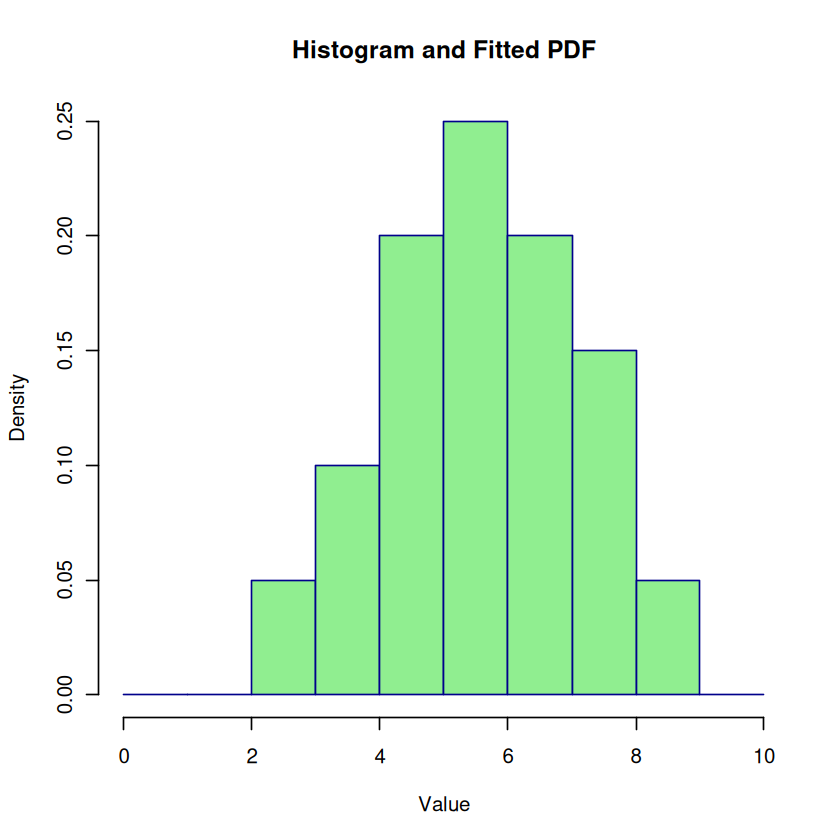

In [86]:
data <- c(3,4,4,5,5,5,5,6,6,6,6,6,7,7,7,7,8,8,8,9)

# Step 1: Plot the histogram with density on the y-axis
hist(data, prob = TRUE, col = "lightgreen", border = "darkblue", 
     xlim = c(lower_limit, upper_limit), 
     xlab = "Value", ylab = "Density", 
     main = "Histogram and Fitted PDF", 
     breaks = seq(lower_limit, upper_limit, by = 1),ylim=c(0,0.25))

# Step 4: Plot the normalized PDF (derived from the derivative)
# Plot the PDF derived from the derivative, making sure it aligns with the original bins
lines(extended_vals_pdf, extended_pdf_vals, col = "green", lwd = 2)

In [130]:
hist_obj <- hist(data, breaks = seq(2.5, 9.5, by = 1), plot = FALSE)


In [135]:
hist_obj$count

[1] 1 2 4 5 4 3 1

In [137]:
# Normalize counts so the total area = 1
normalized_counts <- hist_obj$counts / sum(hist_obj$counts)  # Since bin width = 1

In [138]:
normalized_counts

[1] 0.05 0.10 0.20 0.25 0.20 0.15 0.05

In [ ]:
# Plot manually scaled histogram
plot(hist_obj$mids, normalized_counts, type = "h", lwd = 10, col = "lightgreen",
     xlab = "Value", ylab = "Density", main = "Manually Scaled Histogram",
     xlim = c(3,9), ylim = c(0, max(normalized_counts) * 1.1))

ERROR: Error in eval(expr, envir, enclos): object 'hist_obj' not found


In [88]:
# Plot the PDF (normalized) as probability density
plot(extended_vals_pdf, extended_pdf_vals, type = "l", col = "green", 
     lwd = 2, xlim = c(lower_limit, upper_limit), ylim = c(0, max(extended_pdf_vals) * 1.1),
     xlab = "Value", ylab = "Probability Density", 
     main = "Normalized Probability Density from B-Spline")

ERROR: Error in xy.coords(x, y, xlabel, ylabel, log): 'x' and 'y' lengths differ


ERROR: Error in xy.coords(x, y): 'x' and 'y' lengths differ


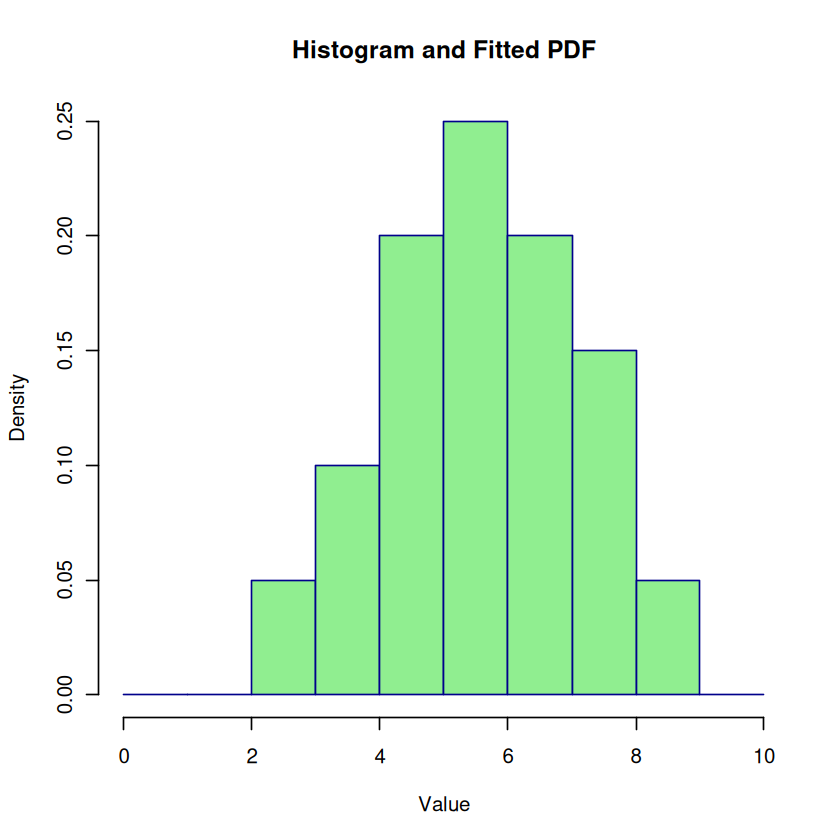

In [89]:
# Overlay the histogram with probability density
hist(data, prob = TRUE, col = "lightgreen", border = "darkblue", 
     xlim = c(lower_limit, upper_limit), 
     xlab = "Value", ylab = "Density", 
     main = "Histogram and Fitted PDF", 
     breaks = seq(lower_limit, upper_limit, by = 1))

# Add the normalized PDF line on top
lines(extended_vals_pdf, extended_pdf_vals, col = "green", lwd = 2)

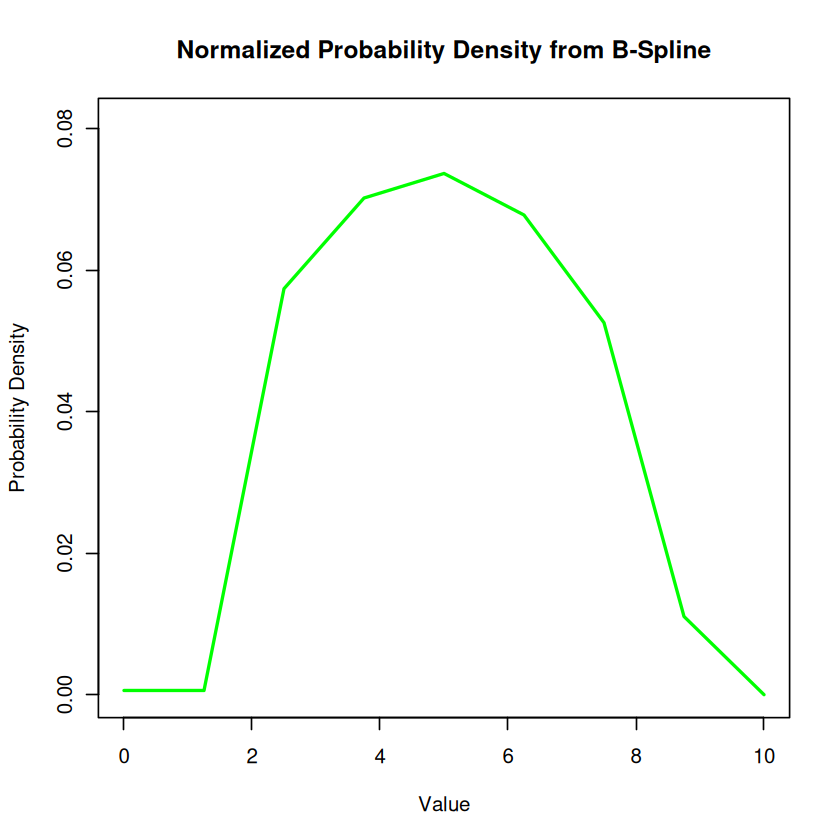

In [90]:
# Adjust the cumulative probabilities to account for the limits
# Include the lower and upper limits, and set the corresponding cumulative probabilities to 0 and 1 respectively
extended_vals <- c(lower_limit, vals, upper_limit)
extended_cumsums <- c(0, cumsums, 1)  # CDF value at upper_limit set to 1

# Fit the B-spline to the adjusted CDF data (forcing the spline to flatten at the boundaries)
cdf_bspline_fit <- lm(extended_cumsums ~ bSpline(extended_vals, degree = 3))

# Calculate the derivative of the fitted CDF (this gives the PDF)
cdf_bspline_derivative <- diff(predict(cdf_bspline_fit)) / diff(extended_vals)

# Normalize the PDF to ensure it integrates to 1 (this should work now)
pdf_integral <- sum(cdf_bspline_derivative) * diff(extended_vals)[1]  # Numerical approximation of integral
cdf_bspline_derivative_normalized <- cdf_bspline_derivative / pdf_integral

# Add a 0 at the end to ensure it drops to zero at the upper limit
extended_pdf_vals <- c(cdf_bspline_derivative_normalized[1], cdf_bspline_derivative_normalized, 0)
extended_vals_pdf <- seq(lower_limit, upper_limit, length.out = length(extended_pdf_vals))

# Plot the normalized PDF
plot(extended_vals_pdf, extended_pdf_vals, type = "l", col = "green", 
     lwd = 2, xlim = c(lower_limit, upper_limit), ylim = c(0, max(extended_pdf_vals) * 1.1),
     xlab = "Value", ylab = "Probability Density", 
     main = "Normalized Probability Density from B-Spline")

In [91]:
tail(extended_pdf_vals, 1)

0

In [6]:
# Fit the B-spline to the extended CDF data (force the spline to meet at limits)
# Use boundary constraints to force the PDF to 0 at both limits (0 and 10)
cdf_bspline_fit <- lm(extended_cumsums ~ bSpline(extended_vals, degree = 3, 
                                                 Boundary = c(0, 1)))

# Show the summary of the fitted B-spline model
summary(cdf_bspline_fit)

Warning message in bSpline(extended_vals, degree = 3, Boundary = c(0, 1)):
“Some 'x' values beyond boundary knots may cause ill-conditioned basis
functions.”



Call:
lm(formula = extended_cumsums ~ bSpline(extended_vals, degree = 3, 
    Boundary = c(0, 1)))

Residuals:
        1         2         3         4         5         6         7         8 
-0.005079  0.039795 -0.026340 -0.029586  0.007117  0.010831  0.008616 -0.005354 

Coefficients:
                                                         Estimate Std. Error
(Intercept)                                              0.005079   0.029217
bSpline(extended_vals, degree = 3, Boundary = c(0, 1))1 -0.058578   0.008481
bSpline(extended_vals, degree = 3, Boundary = c(0, 1))2 -0.092930   0.014960
bSpline(extended_vals, degree = 3, Boundary = c(0, 1))3 -0.107566   0.019844
                                                        t value Pr(>|t|)   
(Intercept)                                               0.174  0.87044   
bSpline(extended_vals, degree = 3, Boundary = c(0, 1))1  -6.907  0.00230 **
bSpline(extended_vals, degree = 3, Boundary = c(0, 1))2  -6.212  0.00342 **
bSpline(extended_vals,

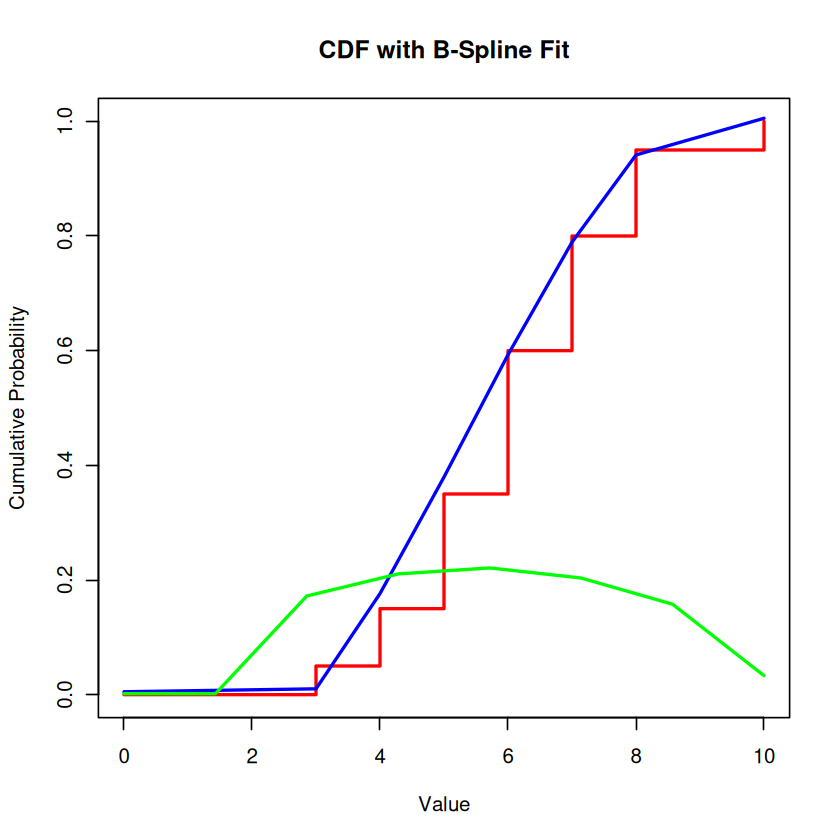

In [7]:
#Plot the CDF with the B-spline fit
plot(extended_vals, extended_cumsums, type = "s", col = "red", lwd = 2, 
     xlim = c(lower_limit, upper_limit), ylim = c(0, 1),
     xlab = "Value", ylab = "Cumulative Probability", 
     main = "CDF with B-Spline Fit")

# Add the B-spline fit to the plot
lines(extended_vals, predict(cdf_bspline_fit), col = "blue", lwd = 2)

# Plot the PDF derived from the derivative (after normalizing)
cdf_bspline_derivative <- diff(predict(cdf_bspline_fit)) / diff(extended_vals)
cdf_bspline_derivative_normalized <- cdf_bspline_derivative / sum(cdf_bspline_derivative)  # Ensuring it's normalized

# Extend the derivative to match the entire range including the last point
extended_pdf_vals <- c(cdf_bspline_derivative_normalized[1], cdf_bspline_derivative_normalized)  # Add the first value at the start
extended_vals_pdf <- seq(lower_limit, upper_limit, length.out = length(extended_pdf_vals))

# Plot the PDF (green curve) derived from the B-spline fit
lines(extended_vals_pdf, extended_pdf_vals, col = "green", lwd = 2)

In [38]:
as.list(new_values)

[[1]]
[1] 1

[[2]]
[1] 1.080808

[[3]]
[1] 1.161616

[[4]]
[1] 1.242424

[[5]]
[1] 1.323232

[[6]]
[1] 1.40404

[[7]]
[1] 1.484848

[[8]]
[1] 1.565657

[[9]]
[1] 1.646465

[[10]]
[1] 1.727273

[[11]]
[1] 1.808081

[[12]]
[1] 1.888889

[[13]]
[1] 1.969697

[[14]]
[1] 2.050505

[[15]]
[1] 2.131313

[[16]]
[1] 2.212121

[[17]]
[1] 2.292929

[[18]]
[1] 2.373737

[[19]]
[1] 2.454545

[[20]]
[1] 2.535354

[[21]]
[1] 2.616162

[[22]]
[1] 2.69697

[[23]]
[1] 2.777778

[[24]]
[1] 2.858586

[[25]]
[1] 2.939394

[[26]]
[1] 3.020202

[[27]]
[1] 3.10101

[[28]]
[1] 3.181818

[[29]]
[1] 3.262626

[[30]]
[1] 3.343434

[[31]]
[1] 3.424242

[[32]]
[1] 3.505051

[[33]]
[1] 3.585859

[[34]]
[1] 3.666667

[[35]]
[1] 3.747475

[[36]]
[1] 3.828283

[[37]]
[1] 3.909091

[[38]]
[1] 3.989899

[[39]]
[1] 4.070707

[[40]]
[1] 4.151515

[[41]]
[1] 4.232323

[[42]]
[1] 4.313131

[[43]]
[1] 4.393939

[[44]]
[1] 4.474747

[[45]]
[1] 4.555556

[[46]]
[1] 4.636364

[[47]]
[1] 4.717172

[[48]]
[1] 4.79798

[[49]]
[1] 4.878788

[[50]]
[1] 4.959596

[[51]]
[1] 5.040404

[[52]]
[1] 5.121212

[[53]]
[1] 5.20202

[[54]]
[1] 5.282828

[[55]]
[1] 5.363636

[[56]]
[1] 5.444444

[[57]]
[1] 5.525253

[[58]]
[1] 5.606061

[[59]]
[1] 5.686869

[[60]]
[1] 5.767677

[[61]]
[1] 5.848485

[[62]]
[1] 5.929293

[[63]]
[1] 6.010101

[[64]]
[1] 6.090909

[[65]]
[1] 6.171717

[[66]]
[1] 6.252525

[[67]]
[1] 6.333333

[[68]]
[1] 6.414141

[[69]]
[1] 6.494949

[[70]]
[1] 6.575758

[[71]]
[1] 6.656566

[[72]]
[1] 6.737374

[[73]]
[1] 6.818182

[[74]]
[1] 6.89899

[[75]]
[1] 6.979798

[[76]]
[1] 7.060606

[[77]]
[1] 7.141414

[[78]]
[1] 7.222222

[[79]]
[1] 7.30303

[[80]]
[1] 7.383838

[[81]]
[1] 7.464646

[[82]]
[1] 7.545455

[[83]]
[1] 7.626263

[[84]]
[1] 7.707071

[[85]]
[1] 7.787879

[[86]]
[1] 7.868687

[[87]]
[1] 7.949495

[[88]]
[1] 8.030303

[[89]]
[1] 8.111111

[[90]]
[1] 8.191919

[[91]]
[1] 8.272727

[[92]]
[1] 8.353535

[[93]]
[1] 8.434343

[[94]]
[1] 8.515152

[[95]]
[1] 8.59596

[[96]]
[1] 8.676768

[[97]]
[1] 8.757576

[[98]]
[1] 8.838384

[[99]]
[1] 8.919192

[[100]]
[1] 9

In [32]:
predict(cdf_bspline_fit,as.list(new_values))

Warning message in bSpline(extended_vals, degree = 3L, knots = numeric(0), Boundary.knots = c(0, :
“Some 'x' values beyond boundary knots may cause ill-conditioned basis
functions.”


1           2           3           4           5           6 
0.005079018 0.010204610 0.176339645 0.379586167 0.592883115 0.789169429 
          7           8 
0.941384049 1.005353968

In [44]:
predictions <- predict(cdf_bspline_fit, newx = new_values, coef = cdf_bspline_fit$coefficients) 


In [50]:
cdf_bspline_fit$coefficients

(Intercept) 
                                            0.005079018 
bSpline(extended_vals, degree = 3, Boundary = c(0, 1))1 
                                           -0.058577823 
bSpline(extended_vals, degree = 3, Boundary = c(0, 1))2 
                                           -0.092929691 
bSpline(extended_vals, degree = 3, Boundary = c(0, 1))3 
                                           -0.107565782

ERROR: Error in xy.coords(x, y): 'x' and 'y' lengths differ


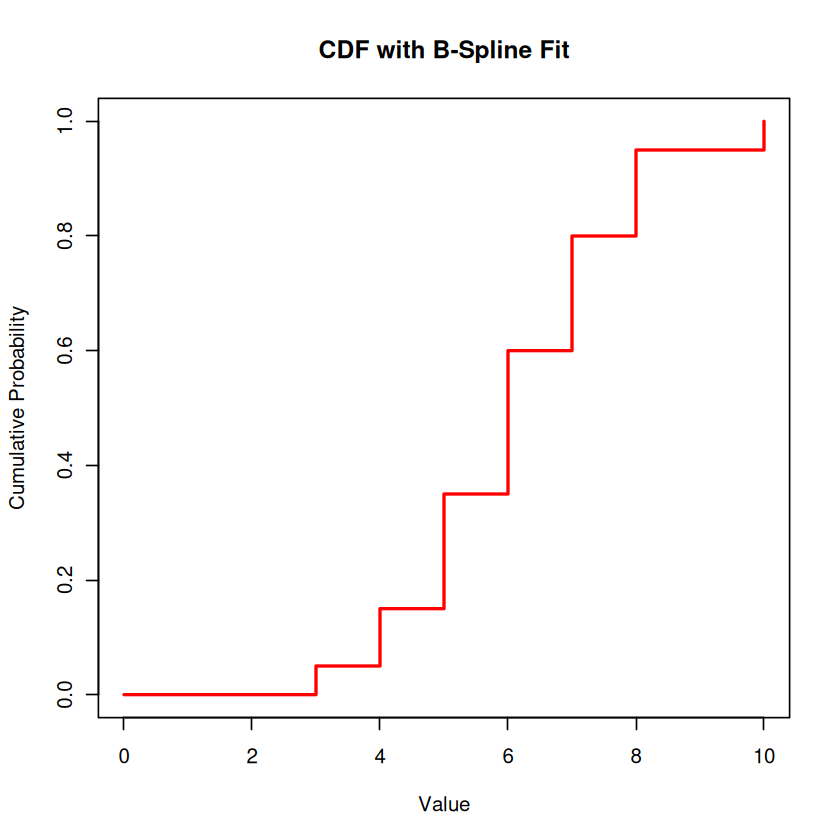

In [45]:
# Plot the original data and the predictions

#Plot the CDF with the B-spline fit
plot(extended_vals, extended_cumsums, type = "s", col = "red", lwd = 2, 
     xlim = c(lower_limit, upper_limit), ylim = c(0, 1),
     xlab = "Value", ylab = "Cumulative Probability", 
     main = "CDF with B-Spline Fit")

lines(new_values, predictions, col = "red")

In [37]:
new_values<-seq(lower_limit+1, upper_limit-1, length.out = 100)

In [15]:
cdf_bspline_derivative <- diff(predict(cdf_bspline_fit,as.list(new_values))) / diff(new_values)
cdf_bspline_derivative_normalized <- cdf_bspline_derivative / sum(cdf_bspline_derivative)  # Ensuring it's normalized


Warning message in bSpline(extended_vals, degree = 3L, knots = numeric(0), Boundary.knots = c(0, :
“Some 'x' values beyond boundary knots may cause ill-conditioned basis
functions.”
Warning message in diff(predict(cdf_bspline_fit, as.list(new_values)))/diff(new_values):
“longer object length is not a multiple of shorter object length”


In [18]:
extended_pdf_vals <- c(0, cdf_bspline_derivative_normalized)  # Add the first value at the start


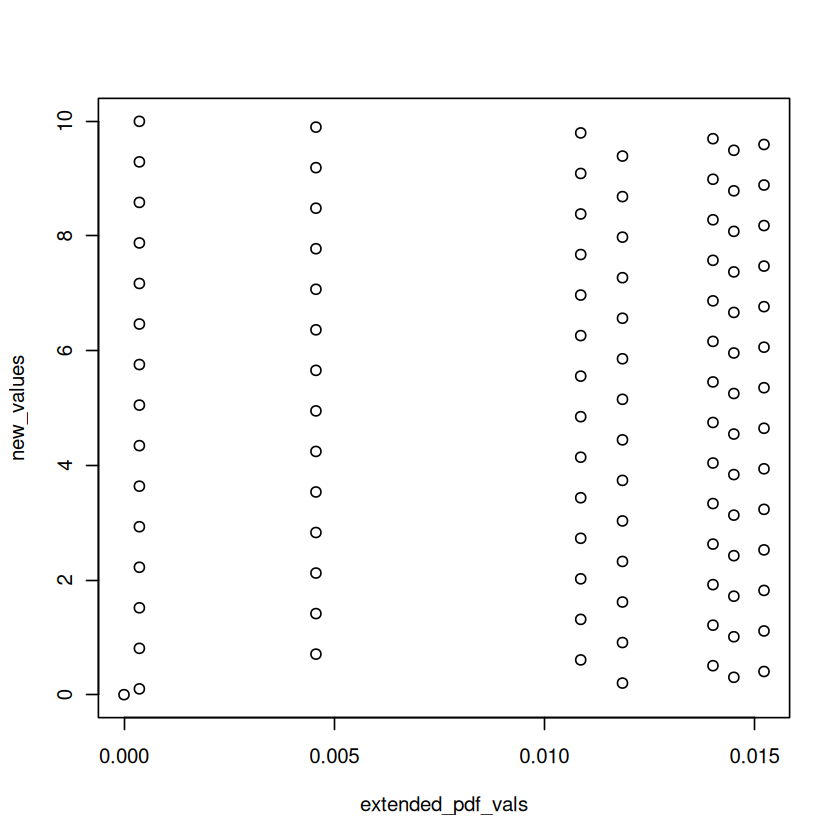

In [26]:
plot(extended_pdf_vals,new_values)

In [ ]:
# Plot the PDF derived from the derivative (after normalizing)
cdf_bspline_derivative <- diff(predict(cdf_bspline_fit)) / diff(extended_vals)
cdf_bspline_derivative_normalized <- cdf_bspline_derivative / sum(cdf_bspline_derivative)  # Ensuring it's normalized

# Extend the derivative to match the entire range including the last point
extended_pdf_vals <- c(cdf_bspline_derivative_normalized[1], cdf_bspline_derivative_normalized)  # Add the first value at the start
extended_vals_pdf <- seq(lower_limit, upper_limit, length.out = length(extended_pdf_vals))

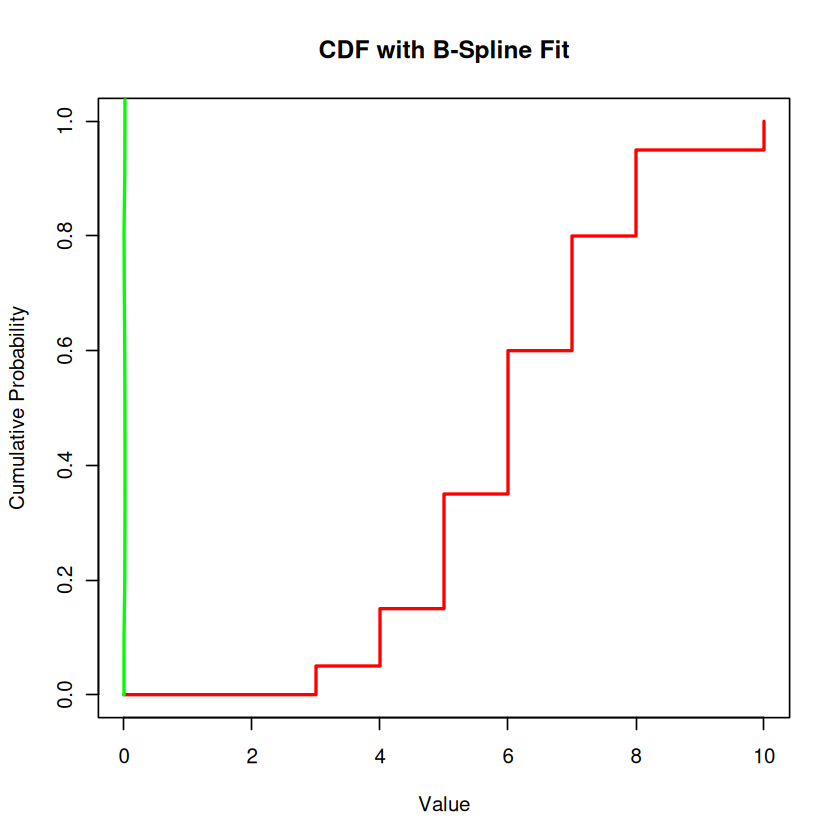

In [27]:
#Plot the CDF with the B-spline fit
plot(extended_vals, extended_cumsums, type = "s", col = "red", lwd = 2, 
     xlim = c(lower_limit, upper_limit), ylim = c(0, 1),
     xlab = "Value", ylab = "Cumulative Probability", 
     main = "CDF with B-Spline Fit")

# Plot the PDF (green curve) derived from the B-spline fit
lines( extended_pdf_vals,new_values,col = "green", lwd = 2)

In [ ]:
# Plot the PDF (green curve) derived from the B-spline fit
lines(extended_vals_pdf, extended_pdf_vals, col = "green", lwd = 2)

[1]  0.0000000  0.1010101  0.2020202  0.3030303  0.4040404  0.5050505
  [7]  0.6060606  0.7070707  0.8080808  0.9090909  1.0101010  1.1111111
 [13]  1.2121212  1.3131313  1.4141414  1.5151515  1.6161616  1.7171717
 [19]  1.8181818  1.9191919  2.0202020  2.1212121  2.2222222  2.3232323
 [25]  2.4242424  2.5252525  2.6262626  2.7272727  2.8282828  2.9292929
 [31]  3.0303030  3.1313131  3.2323232  3.3333333  3.4343434  3.5353535
 [37]  3.6363636  3.7373737  3.8383838  3.9393939  4.0404040  4.1414141
 [43]  4.2424242  4.3434343  4.4444444  4.5454545  4.6464646  4.7474747
 [49]  4.8484848  4.9494949  5.0505051  5.1515152  5.2525253  5.3535354
 [55]  5.4545455  5.5555556  5.6565657  5.7575758  5.8585859  5.9595960
 [61]  6.0606061  6.1616162  6.2626263  6.3636364  6.4646465  6.5656566
 [67]  6.6666667  6.7676768  6.8686869  6.9696970  7.0707071  7.1717172
 [73]  7.2727273  7.3737374  7.4747475  7.5757576  7.6767677  7.7777778
 [79]  7.8787879  7.9797980  8.0808081  8.1818182  8.2828283  8.3838384
 [85]  8.4848485  8.5858586  8.6868687  8.7878788  8.8888889  8.9898990
 [91]  9.0909091  9.1919192  9.2929293  9.3939394  9.4949495  9.5959596
 [97]  9.6969697  9.7979798  9.8989899 10.0000000

In [115]:
# Values representing the bin edges (right edges of bins)
vals <- c(3, 4, 5, 6, 7, 8)

# Cumulative probabilities for these bins
cumsums <- c(0.05, 0.15, 0.35, 0.6, 0.8, 0.95)

# Define the limits
lower_limit <- 0
upper_limit <- 10

# Adjust the cumulative probabilities to account for the limits
extended_vals <- c(lower_limit, vals, upper_limit)
extended_cumsums <- c(0, cumsums, 1)

# Fit the B-spline to the extended CDF data (force the spline to meet at limits)
library(splines2)
cdf_bspline_fit <- lm(extended_cumsums ~ bSpline(extended_vals, degree = 3))

# Show the summary of the fitted B-spline model
print(summary(cdf_bspline_fit))


Call:
lm(formula = extended_cumsums ~ bSpline(extended_vals, degree = 3))

Residuals:
        1         2         3         4         5         6         7         8 
-0.005079  0.039795 -0.026340 -0.029586  0.007117  0.010831  0.008616 -0.005354 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                          0.005079   0.029217   0.174   0.8704    
bSpline(extended_vals, degree = 3)1 -0.585778   0.084812  -6.907   0.0023 ** 
bSpline(extended_vals, degree = 3)2  1.251039   0.070096  17.847 5.79e-05 ***
bSpline(extended_vals, degree = 3)3  1.000275   0.041362  24.184 1.73e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02937 on 4 degrees of freedom
Multiple R-squared:  0.997,	Adjusted R-squared:  0.9947 
F-statistic: 442.7 on 3 and 4 DF,  p-value: 1.689e-05



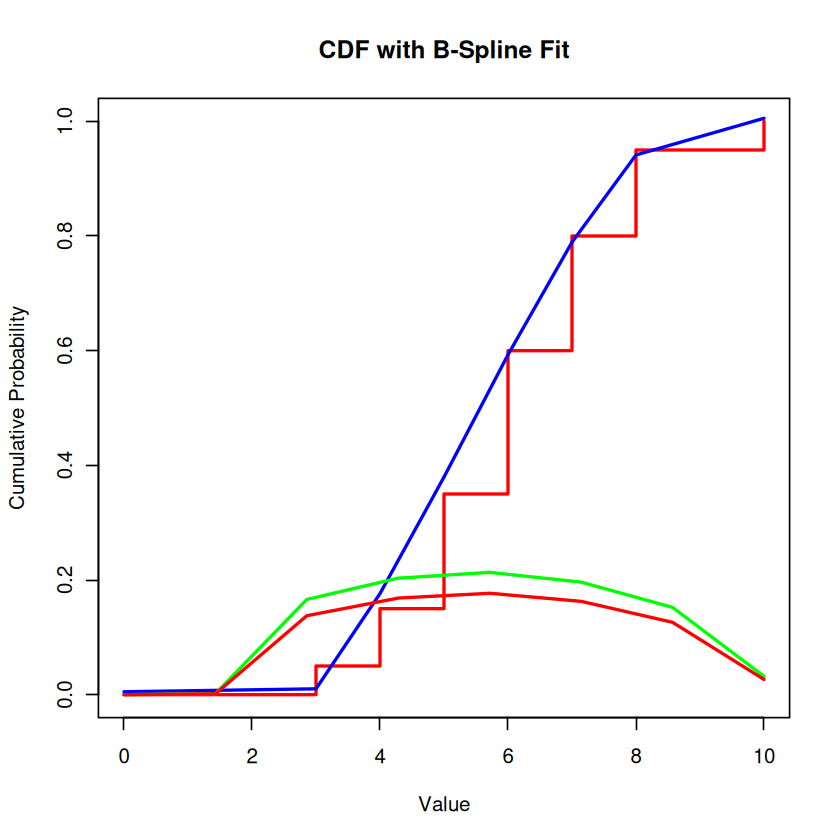

In [124]:
# Create the plot for cumulative distribution function
plot(extended_vals, extended_cumsums, type = "s", col = "red", lwd = 2, 
     xlim = c(lower_limit, upper_limit), ylim = c(0, 1),
     xlab = "Value", ylab = "Cumulative Probability", 
     main = "CDF with B-Spline Fit")

# Add the B-spline fit to the plot
lines(extended_vals, predict(cdf_bspline_fit), col = "blue", lwd = 2)

# Calculate the derivative of the fitted CDF (PDF)
cdf_bspline_derivative <- diff(predict(cdf_bspline_fit)) / diff(extended_vals)

# Extend the derivative to match the entire range including the last point (upper limit)
extended_pdf_vals <- c(0, cdf_bspline_derivative)  # Add the first value at the start
extended_vals_pdf <- seq(lower_limit, upper_limit, length.out = length(extended_pdf_vals))

# Plot the PDF derived from the derivative
lines(extended_vals_pdf, extended_pdf_vals, col = "green", lwd = 2)

# Compute the integral of the PDF (sum of areas)
pdf_integral <- sum(extended_pdf_vals) * (upper_limit - lower_limit) / length(extended_pdf_vals)

# Normalize the PDF (make sure the integral is 1)
pdf_normalized <- extended_pdf_vals / pdf_integral

# Plot the normalized PDF
lines(extended_vals_pdf, pdf_normalized, col = "red", lwd = 2)

In [118]:
pdf_normalized

2           2           3           4           5           6 
0.001414081 0.001414081 0.137503184 0.168218846 0.176537173 0.162458166 
          7           8 
0.125981825 0.026472645

In [97]:
cdf_bspline_derivative 

2          3          4          5          6          7          8 
0.01617049 0.10429970 0.19826799 0.24080852 0.21661098 0.13817674 0.02674032

In [106]:
pdf_normalized

2          2          3          4          5          6          7 
0.01351419 0.01351419 0.08716655 0.16569880 0.20125127 0.18102862 0.11547865 
         8 
0.02234773

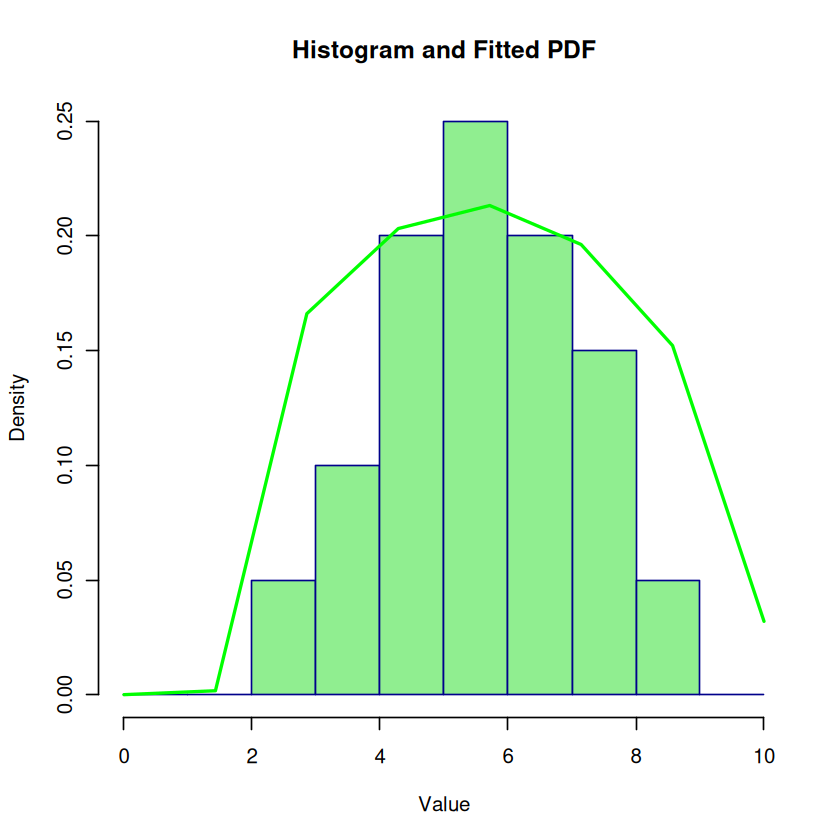

In [125]:
# Overlay the histogram with probability density
hist(data, prob = TRUE, col = "lightgreen", border = "darkblue", 
     xlim = c(lower_limit, upper_limit), 
     xlab = "Value", ylab = "Density", 
     main = "Histogram and Fitted PDF", 
     breaks = seq(lower_limit, upper_limit, by = 1))

# Add the normalized PDF line on top
lines(extended_vals_pdf, extended_pdf_vals, col = "green", lwd = 2)

In [127]:
data/sum(data)

[1] 0.02459016 0.03278689 0.03278689 0.04098361 0.04098361 0.04098361
 [7] 0.04098361 0.04918033 0.04918033 0.04918033 0.04918033 0.04918033
[13] 0.05737705 0.05737705 0.05737705 0.05737705 0.06557377 0.06557377
[19] 0.06557377 0.07377049

In [102]:
extended_vals_pdf

[1]  0.000000  1.428571  2.857143  4.285714  5.714286  7.142857  8.571429
[8] 10.000000

In [104]:
extended_pdf_vals

2          2          3          4          5          6          7 
0.01617049 0.01617049 0.10429970 0.19826799 0.24080852 0.21661098 0.13817674 
         8 
0.02674032

In [128]:
data

[1] 3 4 4 5 5 5 5 6 6 6 6 6 7 7 7 7 8 8 8 9